# Plane Crash Analysis — Failure-Mode Theme Discovery (1908–2009)

**Goal.** Across ~5,200 aviation accidents, what recurring *failure modes* show up in the
free-text crash summaries? Rather than predicting causes, this notebook uses unsupervised
NLP to let themes emerge, and reports them honestly.

**Reworked from the original coursework:** reframed as descriptive theme discovery (not
"cause prediction"), with cleaned data handling, a sparse-friendly 2-D projection, written
findings, and a limitations section.

> Dataset: the public *"Airplane Crashes and Fatalities Since 1908"* CSV. Point the path
> below at your local copy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD  # PCA for sparse TF-IDF matrices

RANDOM_STATE = 0
sns.set_theme(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


## 1. Load the data

In [2]:
df = pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908.csv")
print(df.shape)
df.head()

(5268, 13)


,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


## 2. Clean & derive fields

The raw data is messy: inconsistent dates, free-text locations, and sparse early records.
We parse a clean `Year` and `Country`, coerce the numeric columns, and derive `Survivors`
*carefully* — only where both `Aboard` and `Fatalities` are known, clipped at zero so
inconsistent records can't produce negative survivors.

In [3]:
def extract_year(date):
    try:
        return int(str(date).split("/")[2])
    except (IndexError, ValueError):
        return np.nan

def extract_country(location):
    if not isinstance(location, str):
        return "Unknown"
    return location.split(",")[-1].strip().lower()

df["Year"] = df["Date"].apply(extract_year)
df["Country"] = df["Location"].apply(extract_country)

for col in ["Aboard", "Fatalities", "Ground"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Survivors"] = (df["Aboard"] - df["Fatalities"]).clip(lower=0)
df.loc[df["Aboard"].isna() | df["Fatalities"].isna(), "Survivors"] = np.nan

df[["Date", "Year", "Country", "Aboard", "Fatalities", "Survivors"]].head()

,Date,Year,Country,Aboard,Fatalities,Survivors
0,09/17/1908,1908,virginia,2.0,1.0,1.0
1,07/12/1912,1912,new jersey,5.0,5.0,0.0
2,08/06/1913,1913,canada,1.0,1.0,0.0
3,09/09/1913,1913,over the north sea,20.0,14.0,6.0
4,10/17/1913,1913,germany,30.0,30.0,0.0


## 3. Exploratory analysis

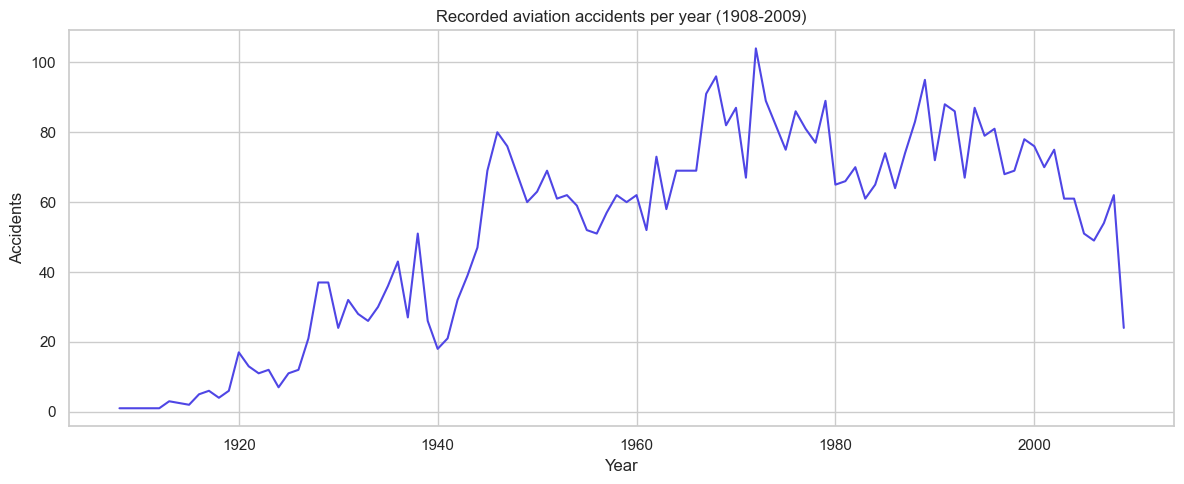

In [4]:
per_year = df.dropna(subset=["Year"]).groupby("Year").size()

plt.figure(figsize=(12, 5))
plt.plot(per_year.index, per_year.values, color="#4f46e5")
plt.title("Recorded aviation accidents per year (1908-2009)")
plt.xlabel("Year")
plt.ylabel("Accidents")
plt.tight_layout()
plt.show()

In [5]:
print("Top operators by accident count:")
display(df["Operator"].value_counts().head(15))

print("\nTop countries/regions by accident count:")
display(df["Country"].value_counts().head(15))

Top operators by accident count:


Operator
Aeroflot                               179
Military - U.S. Air Force              176
Air France                              70
Deutsche Lufthansa                      65
Air Taxi                                44
China National Aviation Corporation     44
United Air Lines                        44
Military - U.S. Army Air Forces         43
Pan American World Airways              41
Military - U.S. Navy                    36
American Airlines                       36
US Aerial Mail Service                  36
Military - Royal Air Force              36
Indian Airlines                         34
KLM Royal Dutch Airlines                33
Name: count, dtype: int64


Top countries/regions by accident count:


Country
brazil        189
alaska        177
russia        175
canada        149
colombia      149
california    143
france        133
england       105
india          99
china          88
indonesia      87
mexico         83
italy          79
germany        79
australia      78
Name: count, dtype: int64

In [6]:
df["Decade"] = (df["Year"] // 10 * 10)
by_decade = df.dropna(subset=["Decade"]).groupby("Decade").agg(
    accidents=("Year", "size"),
    total_aboard=("Aboard", "sum"),
    total_fatalities=("Fatalities", "sum"),
)
by_decade["fatality_rate"] = by_decade["total_fatalities"] / by_decade["total_aboard"]
by_decade

,accidents,total_aboard,total_fatalities,fatality_rate
Decade,,,,
1900,1,2.0,1.0,0.500000
1910,27,419.0,392.0,0.935561
1920,178,761.0,633.0,0.831800
1930,323,2326.0,1849.0,0.794927
1940,510,9634.0,8011.0,0.831534
1950,596,14070.0,11059.0,0.785999
1960,721,21045.0,16619.0,0.789689
1970,837,28158.0,21126.0,0.750266
1980,717,26361.0,17864.0,0.677668


## 4. Failure-mode themes via unsupervised NLP

We TF-IDF the crash summaries and cluster them with K-Means (`k=5`), then project to 2-D
with TruncatedSVD so the clusters are legible. `max_df`/`min_df` trim boilerplate and very
rare tokens.

In [7]:
summaries = df["Summary"].dropna()

vectorizer = TfidfVectorizer(stop_words="english", max_df=0.5, min_df=5)
X = vectorizer.fit_transform(summaries)

K = 5
kmeans = MiniBatchKMeans(n_clusters=K, random_state=RANDOM_STATE, n_init="auto")
labels = kmeans.fit_predict(X)

In [8]:
terms = vectorizer.get_feature_names_out()
order = kmeans.cluster_centers_.argsort()[:, ::-1]
for i in range(K):
    top = [terms[j] for j in order[i, :12]]
    print(f"Cluster {i}: " + ", ".join(top))

Cluster 0: shot, air, land, helicopter, attempting, killed, collision, midair, rebels, missile, aircraft, aboard
Cluster 1: aircraft, taking, flight, plane, shortly, pilot, control, sea, crew, minutes, lost, failure
Cluster 2: approach, weather, conditions, poor, mountain, flight, pilot, vfr, adverse, fog, aircraft, terrain
Cluster 3: engine, en, route, plane, takeoff, cargo, mountain, failure, struck, landing, emergency, lost
Cluster 4: runway, short, landing, aircraft, approach, plane, ground, attempting, pilot, land, struck, crew


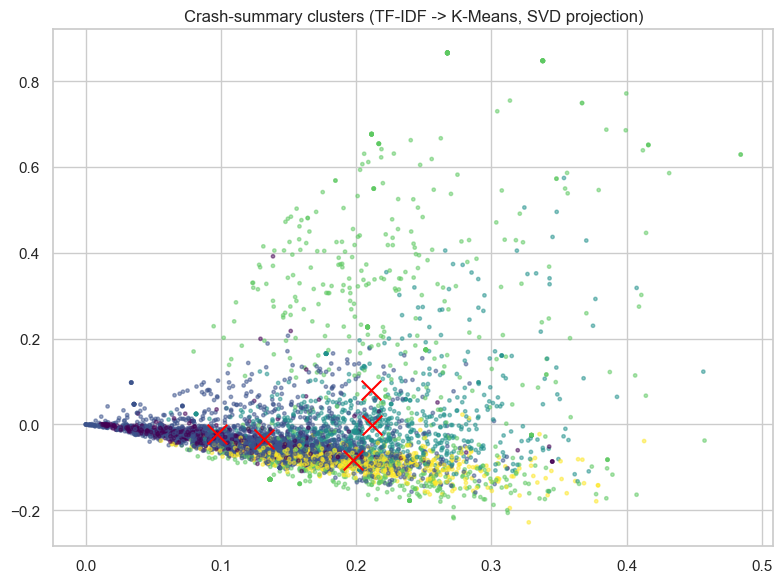

In [9]:
svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
coords = svd.fit_transform(X)
centers = svd.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=labels, cmap="viridis", s=6, alpha=0.5)
plt.scatter(centers[:, 0], centers[:, 1], marker="x", s=200, c="red")
plt.title("Crash-summary clusters (TF-IDF -> K-Means, SVD projection)")
plt.tight_layout()
plt.show()

## 5. Assigning a new summary to a theme

This is *nearest-cluster assignment*, not prediction: given a short phrase, which existing
theme is it closest to? Useful for triage/exploration, but it makes no causal claim.

In [10]:
def assign_theme(text):
    return int(kmeans.predict(vectorizer.transform([text]))[0])

for phrase in [
    "engine failure shortly after takeoff",
    "struck mountain in poor weather",
    "disappeared en route over the ocean",
]:
    print(f"{phrase!r} -> theme {assign_theme(phrase)}")

'engine failure shortly after takeoff' -> theme 3
'struck mountain in poor weather' -> theme 2
'disappeared en route over the ocean' -> theme 3


## Findings & limitations

The five clusters line up with well-known aviation risk categories — a good sanity check
that the unsupervised method found something real:

- **Hostile action & midair events** (shot down, missiles, midair collisions)
- **Loss of control shortly after takeoff** (often ending at sea)
- **Weather & poor visibility on approach** (fog, VFR into terrain)
- **Engine failure en route and on takeoff** (including cargo flights)
- **Runway & landing incidents** (landing short, striking ground)

**Limitations**
- `k=5` was chosen heuristically — justify it with an elbow/silhouette sweep.
- Summaries are post-hoc, human-written text, so they carry reporting bias.
- This is **descriptive**, not causal; theme assignment is not failure prediction.
- Early-era records are sparse and inconsistent (missing `Aboard`/`Time`).

**Next steps:** silhouette/elbow for `k`, topic modeling (NMF/LDA) for softer themes, and
tracking how the theme mix shifts by decade.